interactive(children=(FloatSlider(value=1.0, description='ku', max=3.0, min=-1.0), Output()), _dom_classes=('w…

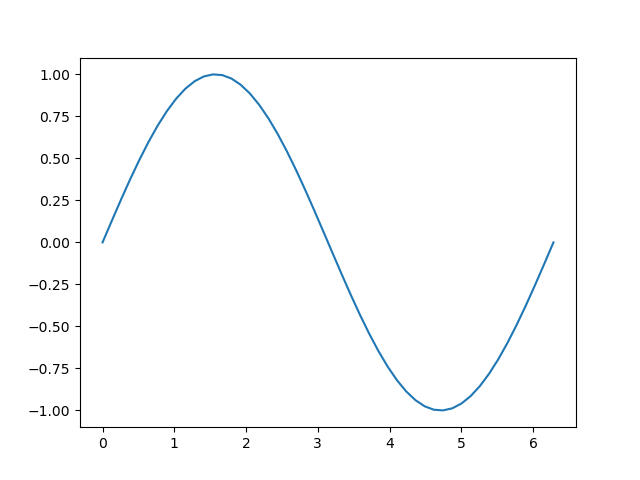

In [ ]:
# %matplotlib ipympl
%matplotlib widget
from ipywidgets import *
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi)
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
line, = ax.plot(x, np.sin(x))

def update(ku = 1.0):
    line.set_ydata(np.sin(ku * x))
    fig.canvas.draw_idle()

interact(update);


In [7]:
%load_ext autoreload
%autoreload 2

import numpy as np
from numpy import pi
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
colors = ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C0','C1','C2','C3','C4','C5','C6','C7','C8']

from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import sample_square

from blochK.observable import exp_value_O,conductivity_list_of_operators, local_dos_QPI, find_Gamma
import blochK

from alter_surf.utils3D import project_doublelayer
from alter_surf.hamiltonian_CuMnAs import H_3D_fct, H_slab_fct, create_H_CuMnAs_slab, create_H_CuMnAs_3D

from numpy import cos, sin 

from tqdm import tqdm
import pickle

#create a custom colormap bkr
# grab the endpoints from bwr
cmap_bwr = matplotlib.colormaps["bwr"]
# define your own colormap: blue → black → red
colors = [cmap_bwr(0.0), (0, 0, 0, 1),cmap_bwr(1.0)]
cmap_bkr = LinearSegmentedColormap.from_list("bkr", colors, N=256)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


First layer conductivity: 
 [[0.08391266 0.0311499 ]
 [0.0311499  0.10428823]]
Second layer conductivity: 
 [[ 0.09152575 -0.02852429]
 [-0.02852429  0.10998569]]


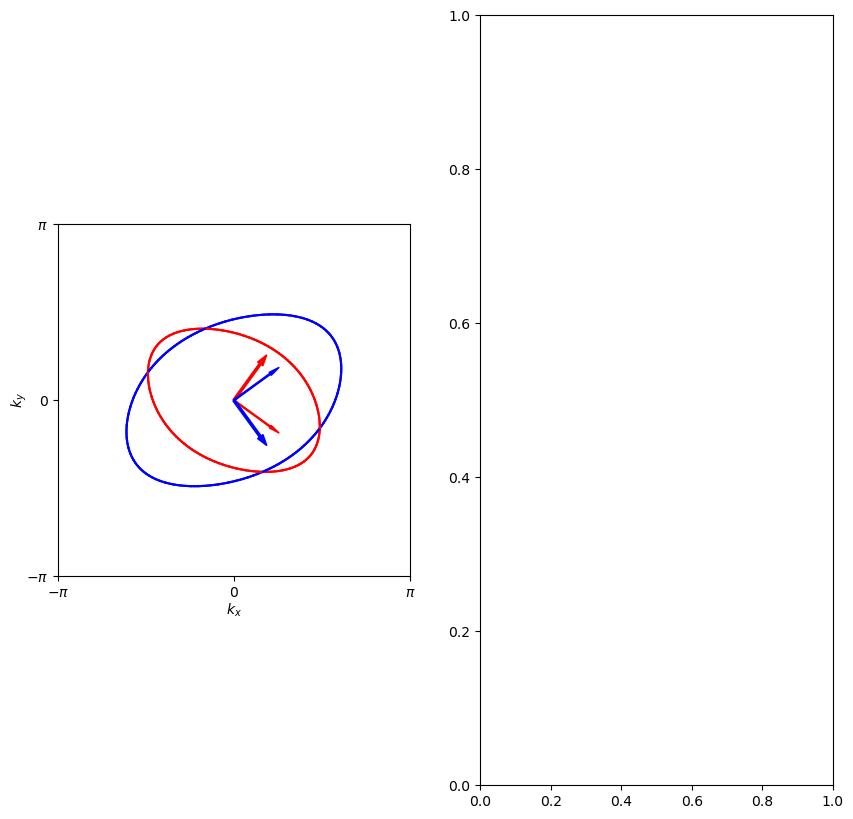

In [93]:
def H_fct(kx,ky,t=1, delta=0,tp=0,mu=0):
    Hk = np.zeros((2,2,*kx.shape),dtype=complex)
    eta = 0.2
    Hk[0,0] = -2*t*(1+delta)*cos((kx+(1+eta)*ky)/2) - 2*t*(1-delta)*cos((kx-(1+eta)*ky)/2) - mu
    Hk[1,1] = -2*t*(1-delta)*cos(((1-eta)*kx+ky)/2) - 2*t*(1+delta)*cos(((1-eta)*kx-ky)/2) - mu
    Hk[0,1] = -2*1.3*tp*cos(kx) - 2*tp*cos(ky)
    Hk[1,0] = np.conj(Hk[0,1])

    return Hk

H = blochK.Hamiltonian2D(H_fct, param=dict(t=1, delta=0.3,tp=0.,mu=-3.0))
H.add_operator('layer',np.array([1,-1]))

fig,axs = plt.subplots(1,2,figsize=(10,10))
plot_FS(axs[0], H,coloring_operator=H.operator.layer,cmap=cmap_bkr)  

conds = conductivity_list_of_operators(H, list_of_operators=[H.operator.layer>0,H.operator.layer<0])


print('First layer conductivity: \n',conds[0])
print('Second layer conductivity: \n',conds[1])


eigvals, eigvecs = np.linalg.eig(conds)

eigvecs = eigvecs * np.sign(eigvecs[:,0,:])[:,np.newaxis,:] #fix the sign of the first eigenvector for better visualization

widths = np.abs(eigvals)
widths = widths / np.max(widths) * 0.2 #normalize widths for better visualization

axs[0].add_patch(matplotlib.patches.Arrow(0,0,*eigvecs[0,:,0],color=cmap_bkr(0.99),label='cond. layer 1',width=widths[0,0]))
axs[0].add_patch(matplotlib.patches.Arrow(0,0,*eigvecs[0,:,1],color=cmap_bkr(0.99),label='cond. layer 1',width=widths[0,1]))

axs[0].add_patch(matplotlib.patches.Arrow(0,0,*eigvecs[1,:,0],color=cmap_bkr(0),label='cond. layer 2',width=widths[1,0]))
axs[0].add_patch(matplotlib.patches.Arrow(0,0,*eigvecs[1,:,1],color=cmap_bkr(0),label='cond. layer 2',width=widths[1,1]))


First layer conductivity: 
 [[0.27856503 0.06012367]
 [0.05131407 0.42632562]]
Second layer conductivity: 
 [[ 0.27856503 -0.06012367]
 [-0.05131407  0.42632562]]


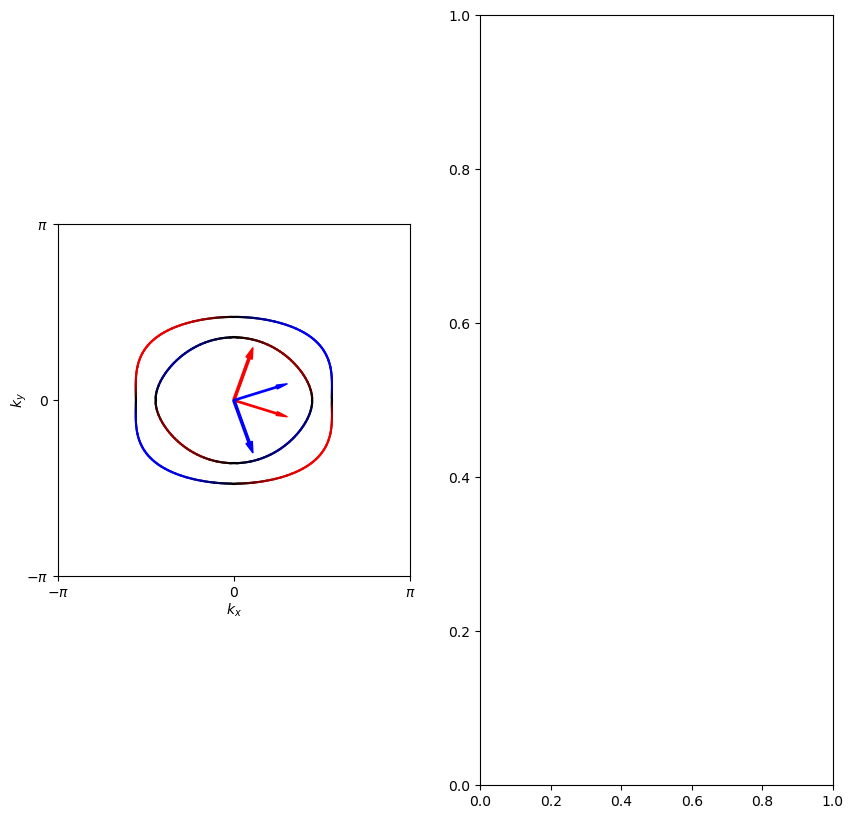

In [117]:
def H_fct(kx,ky,t=1, delta=0,tp=0,mu=0):
    Hk = np.zeros((2,2,*kx.shape),dtype=complex)
    eta = 0.
    theta = 0.1*np.pi
    kxR =  cos(theta)*kx + sin(theta)*ky
    kyR = -sin(theta)*kx + cos(theta)*ky

    kxL =  cos(theta)*kx - sin(theta)*ky
    kyL =  sin(theta)*kx + cos(theta)*ky
    

    Hk[0,0] = -2*t*(1+delta)*cos((kxR+kyR)/2) - 2*t*(1-delta)*cos((kxR-kyR)/2) - mu
    Hk[1,1] = -2*t*(1-delta)*cos((kxL+kyL)/2) - 2*t*(1+delta)*cos((kxL-kyL)/2) - mu
    Hk[0,1] = -2*tp*cos(kx) - 2*tp*cos(ky)
    Hk[1,0] = np.conj(Hk[0,1])

    return Hk

H = blochK.Hamiltonian2D(H_fct, param=dict(t=1, delta=0.3,tp=0.1,mu=-3.0))
H.add_operator('layer',np.array([1,-1]))

fig,axs = plt.subplots(1,2,figsize=(10,10))
plot_FS(axs[0], H,coloring_operator=H.operator.layer,cmap=cmap_bkr)  

conds = conductivity_list_of_operators(H, list_of_operators=[H.operator.layer>0,H.operator.layer<0])


print('First layer conductivity: \n',conds[0])
print('Second layer conductivity: \n',conds[1])


eigvals, eigvecs = np.linalg.eig(conds)

eigvecs = eigvecs * np.sign(eigvecs[:,0,:])[:,np.newaxis,:] #fix the sign of the first eigenvector for better visualization

widths = np.abs(eigvals)
widths = widths / np.max(widths) * 0.2 #normalize widths for better visualization

axs[0].add_patch(matplotlib.patches.Arrow(0,0,*eigvecs[0,:,0],color=cmap_bkr(0.99),label='cond. layer 1',width=widths[0,0]))
axs[0].add_patch(matplotlib.patches.Arrow(0,0,*eigvecs[0,:,1],color=cmap_bkr(0.99),label='cond. layer 1',width=widths[0,1]))

axs[0].add_patch(matplotlib.patches.Arrow(0,0,*eigvecs[1,:,0],color=cmap_bkr(0),label='cond. layer 2',width=widths[1,0]))
axs[0].add_patch(matplotlib.patches.Arrow(0,0,*eigvecs[1,:,1],color=cmap_bkr(0),label='cond. layer 2',width=widths[1,1]))



In [119]:
conds = conductivity_list_of_operators(H, list_of_operators=[np.array([1,1]),np.array([1,-1])])


conds

array([[[ 5.57130063e-01, -6.51377599e-17],
        [-2.89501155e-17,  8.52651246e-01]],

       [[ 1.15800462e-16,  1.20247330e-01],
        [ 1.02628138e-01,  0.00000000e+00]]])